In [ ]:
import pandas as pd
df = pd.read_csv("WineQT.csv")
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def classifica_qual_vinho(df):
  if df["quality"]>=7:
    return True
  else:
    return False

In [ ]:
df["alta qualidade"]=df.apply(classifica_qual_vinho,axis=1)

In [ ]:
df_baixa_qualidade = df[df["alta qualidade"]==False]
df_alta_qualidade = df[df["alta qualidade"]==True]

In [ ]:
df_baixa_qualidade.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,alta qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,False


In [ ]:
df.groupby("alta qualidade")["alta qualidade"].count()

,alta qualidade
alta qualidade,
False,984
True,159


In [ ]:
print("Média de acidez fixa em vinhos de baixa qualidade: ",df_baixa_qualidade["fixed acidity"].mean())
print("Média de acidez fixa em vinhos de alta qualidade: ",df_alta_qualidade["fixed acidity"].mean())

Média de acidez fixa em vinhos de baixa qualidade:  8.22459349593496
Média de acidez fixa em vinhos de alta qualidade:  8.846540880503143


In [ ]:
print("Média de pH em vinhos de baixa qualidade: ",df_baixa_qualidade["pH"].mean())
print("Média de pH em vinhos de alta qualidade: ",df_alta_qualidade["pH"].mean())

Média de pH em vinhos de baixa qualidade:  3.315630081300813
Média de pH em vinhos de alta qualidade:  3.2824528301886797


In [ ]:
print("Média de álcool em vinhos de baixa qualidade: ",df_baixa_qualidade["alcohol"].mean())
print("Média de álcool em vinhos de alta qualidade: ",df_alta_qualidade["alcohol"].mean())

Média de álcool em vinhos de baixa qualidade:  10.266581978319785
Média de álcool em vinhos de alta qualidade:  11.528406708595389


In [ ]:
print("Média de ácido cítrico em vinhos de baixa qualidade: ",df_baixa_qualidade["citric acid"].mean())
print("Média de ácido cítrico em vinhos de alta qualidade: ",df_alta_qualidade["citric acid"].mean())

Média de ácido cítrico em vinhos de baixa qualidade:  0.24851626016260164
Média de ácido cítrico em vinhos de alta qualidade:  0.39119496855345914


In [ ]:
df_pH_bx_qualidade = df_baixa_qualidade.groupby("quality")["pH"].mean()
df_pH_at_qualidade = df_alta_qualidade.groupby("quality")["pH"].mean()

In [ ]:
df_AC_bx_qualidade = df_baixa_qualidade.groupby("quality")["citric acid"].mean()
df_AC_at_qualidade = df_alta_qualidade.groupby("quality")["citric acid"].mean()

In [ ]:
df_FA_bx_qualidade = df_baixa_qualidade.groupby("quality")["fixed acidity"].mean()
df_FA_at_qualidade = df_alta_qualidade.groupby("quality")["fixed acidity"].mean()

In [ ]:
df_alcool_bx_qualidade = df_baixa_qualidade.groupby("quality")["alcohol"].mean()
df_alcool_at_qualidade = df_alta_qualidade.groupby("quality")["alcohol"].mean()

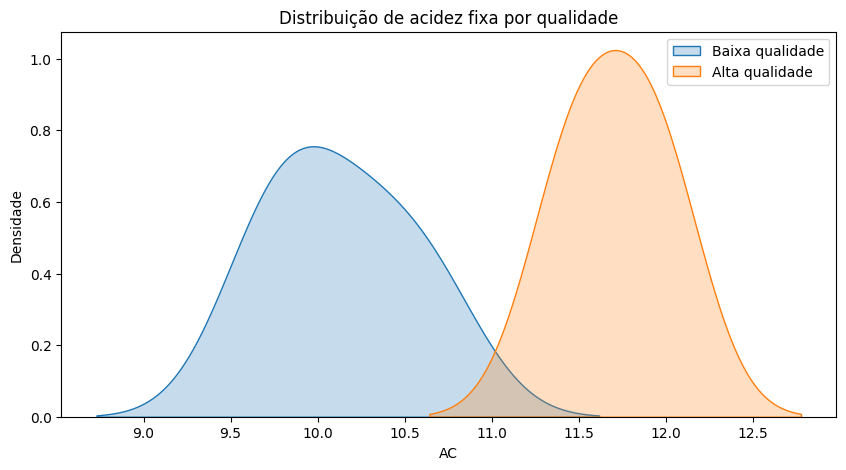

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df_alcool_bx_qualidade,label="Baixa qualidade", fill=True)
sns.kdeplot(data=df_alcool_at_qualidade,label="Alta qualidade", fill=True)
plt.title("Distribuição de acidez fixa por qualidade")
plt.xlabel("AC")
plt.ylabel("Densidade")
plt.legend()
plt.show()
#

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(df_alcool_at_qualidade)
print("Média da acidez cítrica em vinhos de alta qualidade: ")
print("Estatística de teste: {:4f}, valor p:{}".format(stat,p))

if p>0.05:
  print("Não há evidência suficiente para rejeitar a hipótese de normalidade")
else:
  print("Há evidência suficiente para rejeitar a hipótese de normalidade")

Média da acidez cítrica em vinhos de alta qualidade: 
Estatística de teste:  nan, valor p:nan
Há evidência suficiente para rejeitar a hipótese de normalidade


/tmp/ipykernel_2330/1005919101.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_alcool_at_qualidade)


In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
stat, p = mannwhitneyu(df_AC_bx_qualidade.sample(len(df_AC_bx_qualidade)),df_AC_at_qualidade.sample(len(df_AC_at_qualidade)),alternative="less")
print("Estatística de teste U: ",stat)
print("Valor p: ", p)
alpha=0.05
if p>alpha:
  print("Não há evidência suficiente para rejeitar a hipótese nula")
else:
  print("Há evidência suficiente para rejeitar a hipótese nula")

Estatística de teste U:  0.0
Valor p:  0.06666666666666667
Não há evidência suficiente para rejeitar a hipótese nula
